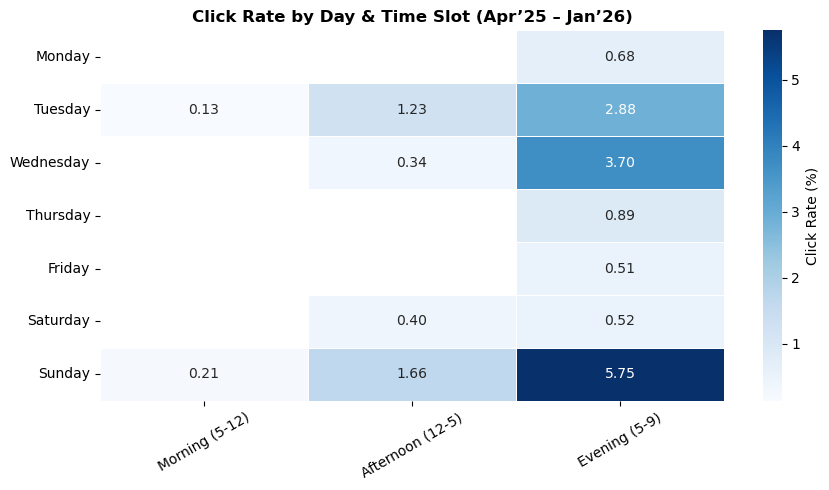

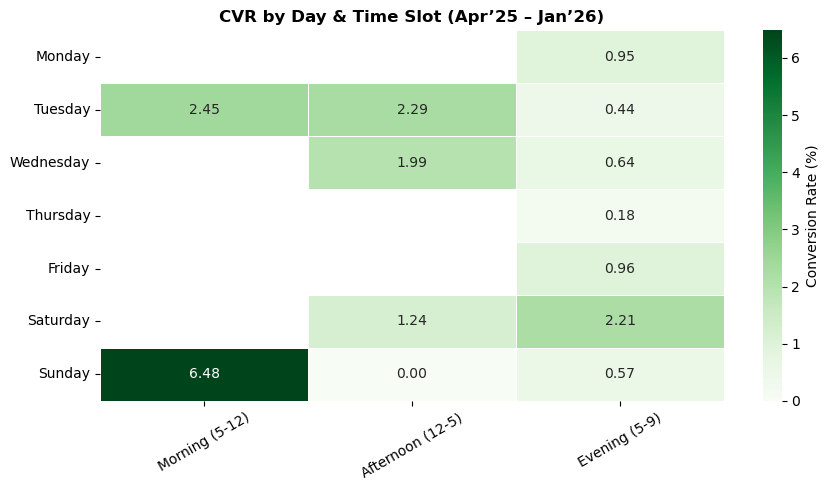

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATA
# -----------------------------
file_path = r"C:\Users\HP\Documents\Durex_Heatmap_Source_Sheet.xlsx"
df = pd.read_excel(file_path)

# -----------------------------
# 2. KEEP REQUIRED COLUMNS
# -----------------------------
df = df[["Day", "Time_Slot", "Delivered", "Clicks", "Orders"]]

df = df.dropna(subset=["Day", "Time_Slot", "Delivered", "Clicks"])
df = df[(df["Delivered"] > 0) & (df["Clicks"] > 0)]

# -----------------------------
# 3. AGGREGATE
# -----------------------------
agg = df.groupby(["Day", "Time_Slot"], as_index=False).agg({
    "Delivered": "sum",
    "Clicks": "sum",
    "Orders": "sum"
})

# -----------------------------
# 4. METRICS
# -----------------------------
agg["Click Rate"] = (agg["Clicks"] / agg["Delivered"]) * 100
agg["CVR"] = (agg["Orders"] / agg["Clicks"]) * 100

# -----------------------------
# 5. PIVOTS
# -----------------------------
click_pivot = agg.pivot(index="Day", columns="Time_Slot", values="Click Rate")
cvr_pivot   = agg.pivot(index="Day", columns="Time_Slot", values="CVR")

# -----------------------------
# 6. ENFORCE ORDER
# -----------------------------
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

time_order = [
    "Morning (5-12)",
    "Afternoon (12-5)",
    "Evening (5-9)"
]

click_pivot = click_pivot.reindex(day_order)[time_order]
cvr_pivot   = cvr_pivot.reindex(day_order)[time_order]

# -----------------------------
# 7. CLICK RATE HEATMAP (SAVE)
# -----------------------------
plt.figure(figsize=(9,5))
sns.heatmap(
    click_pivot,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Click Rate (%)"}
)
plt.title("Click Rate by Day & Time Slot (Apr’25 – Jan’26)", fontsize=12, weight="bold")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("Click_Rate_Heatmap_Apr25_Jan26.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 8. CVR HEATMAP (SAVE)
# -----------------------------
plt.figure(figsize=(9,5))
sns.heatmap(
    cvr_pivot,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Conversion Rate (%)"}
)
plt.title("CVR by Day & Time Slot (Apr’25 – Jan’26)", fontsize=12, weight="bold")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("CVR_Heatmap_Apr25_Jan26.png", dpi=300, bbox_inches="tight")
plt.show()


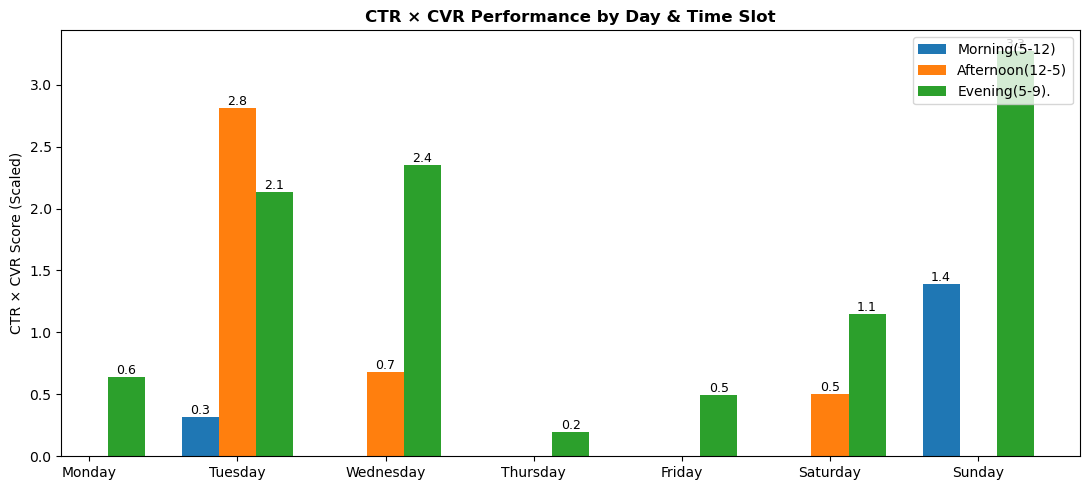

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# LOAD DATA
# -----------------------------
file_path =r"C:\Users\HP\Documents\Durex_Heatmap_Source_Sheet.xlsx"
df = pd.read_excel(file_path)

df = df[["Day", "Time_Slot", "Delivered", "Clicks", "Orders"]]
df = df.dropna()
df = df[(df["Delivered"] > 0) & (df["Clicks"] > 0)]

# -----------------------------
# AGGREGATE
# -----------------------------
agg = df.groupby(["Day", "Time_Slot"], as_index=False).agg({
    "Delivered": "sum",
    "Clicks": "sum",
    "Orders": "sum"
})

# -----------------------------
# METRICS (DECIMAL SAFE)
# -----------------------------
agg["CTR"] = agg["Clicks"] / agg["Delivered"]
agg["CVR"] = agg["Orders"] / agg["Clicks"]

agg["Score"] = agg["CTR"] * agg["CVR"]

# Scale only for visual readability
agg["Display_Score"] = agg["Score"] * 10000

# -----------------------------
# PIVOT FOR GROUPED BARS
# -----------------------------
pivot = agg.pivot(index="Day", columns="Time_Slot", values="Display_Score")

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
slot_order = ["Morning (5-12)", "Afternoon (12-5)", "Evening (5-9)"]

pivot = pivot.reindex(day_order)[slot_order]

# -----------------------------
# BAR POSITIONS
# -----------------------------
x = np.arange(len(pivot.index))
width = 0.25

plt.figure(figsize=(11,5))

bars1 = plt.bar(x - width, pivot[slot_order[0]], width, label="Morning(5-12)")
bars2 = plt.bar(x,         pivot[slot_order[1]], width, label="Afternoon(12-5)")
bars3 = plt.bar(x + width, pivot[slot_order[2]], width, label="Evening(5-9).")

# -----------------------------
# VALUE LABELS
# -----------------------------
def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            plt.text(bar.get_x() + bar.get_width()/2, h,
                     f"{h:.1f}", ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# -----------------------------
# FORMATTING
# -----------------------------
plt.xticks(x, pivot.index)
plt.ylabel("CTR × CVR Score (Scaled)")
plt.title("CTR × CVR Performance by Day & Time Slot", weight="bold")
plt.legend()
plt.tight_layout()

plt.savefig("CTR_CVR_Grouped_By_Day_Time.png", dpi=300, bbox_inches="tight")
plt.show()
